In [ ]:
1.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu (file UCI dùng dấu ";" làm phân tách)
df_mat = pd.read_csv("../data/raw/student-mat.csv", sep=";")
df_por = pd.read_csv("../data/raw/student-por.csv", sep=";")

print("Số dòng - số cột (Math):", df_mat.shape)
print("Số dòng - số cột (Portuguese):", df_por.shape)

df_mat.head()

Số dòng - số cột (Math): (395, 33)
Số dòng - số cột (Portuguese): (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
2.
# Dùng bộ dữ liệu Portuguese (649 bản ghi) làm dữ liệu chính cho đề tài
df = df_por.copy()

# Xem thông tin tổng quan: tên cột, kiểu dữ liệu, có thiếu dữ liệu không
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [ ]:
3.
print("Tổng số giá trị thiếu (null) trong toàn bộ dữ liệu:", df.isnull().sum().sum())

# Kiểm tra có dòng bị lặp (duplicate) không
print("Số dòng bị trùng lặp:", df.duplicated().sum())

Tổng số giá trị thiếu (null) trong toàn bộ dữ liệu: 0
Số dòng bị trùng lặp: 0


In [ ]:
4.
# Thống kê mô tả các cột số
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


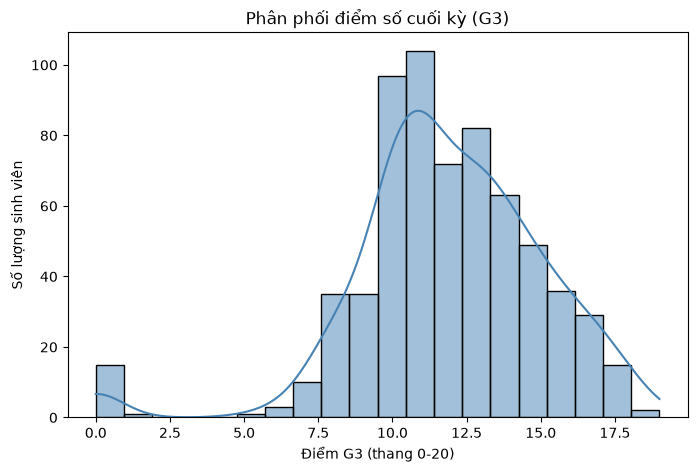

In [ ]:
5.
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True, color='steelblue')
plt.title('Phân phối điểm số cuối kỳ (G3)')
plt.xlabel('Điểm G3 (thang 0-20)')
plt.ylabel('Số lượng sinh viên')
plt.savefig('../results/figures/phan_phoi_G3.png', dpi=150, bbox_inches='tight')
plt.show()

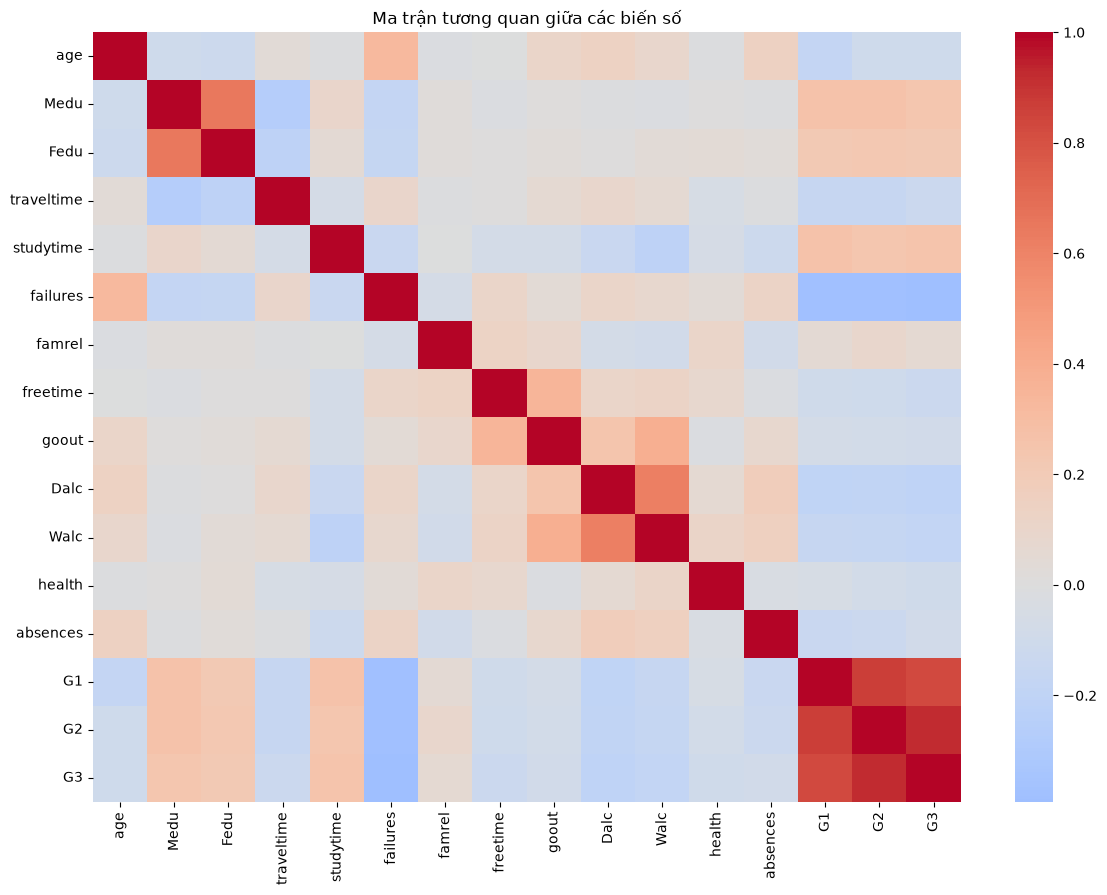

G3           1.000000
G2           0.918548
G1           0.826387
studytime    0.249789
Medu         0.240151
Fedu         0.211800
famrel       0.063361
goout       -0.087641
absences    -0.091379
health      -0.098851
age         -0.106505
Name: G3, dtype: float64


In [ ]:
6.
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Ma trận tương quan giữa các biến số')
plt.savefig('../results/figures/ma_tran_tuong_quan.png', dpi=150, bbox_inches='tight')
plt.show()

# In ra top 10 biến tương quan mạnh nhất với G3
print(corr['G3'].sort_values(ascending=False).head(11))

In [ ]:
7.
# Xem danh sách các cột dạng chữ (categorical)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Các cột categorical:", cat_cols)
print("Số lượng:", len(cat_cols))

# Xem giá trị duy nhất của vài cột để hiểu dữ liệu
for col in cat_cols[:5]:
    print(f"\n{col}: {df[col].unique()}")

Các cột categorical: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Số lượng: 17

school: <StringArray>
['GP', 'MS']
Length: 2, dtype: str

sex: <StringArray>
['F', 'M']
Length: 2, dtype: str

address: <StringArray>
['U', 'R']
Length: 2, dtype: str

famsize: <StringArray>
['GT3', 'LE3']
Length: 2, dtype: str

Pstatus: <StringArray>
['A', 'T']
Length: 2, dtype: str


C:\Users\6\AppData\Local\Temp\ipykernel_8524\3585469333.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [ ]:
8.
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # lưu lại để biết số nào tương ứng giá trị chữ nào

df_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
9.
df_encoded.to_csv('../data/processed/student_data_processed.csv', index=False)
print("Đã lưu dữ liệu đã xử lý vào data/processed/")

Đã lưu dữ liệu đã xử lý vào data/processed/


In [ ]:
10.
from sklearn.model_selection import train_test_split

# Biến mục tiêu: G3 (điểm cuối kỳ)
# Lưu ý: G1, G2 là điểm giữa kỳ - có tương quan RẤT mạnh với G3 (vì là điểm cùng 1 sinh viên)
# Ta sẽ thử 2 kịch bản: CÓ và KHÔNG có G1,G2 để so sánh độ khó của bài toán

X_full = df_encoded.drop(columns=['G3'])          # Kịch bản A: dùng tất cả biến (kể cả G1, G2)
X_without_grades = df_encoded.drop(columns=['G1', 'G2', 'G3'])  # Kịch bản B: không dùng G1, G2

y_reg = df_encoded['G3']  # mục tiêu hồi quy: điểm số cụ thể

print("Số biến đầu vào (kịch bản A - có G1,G2):", X_full.shape[1])
print("Số biến đầu vào (kịch bản B - không G1,G2):", X_without_grades.shape[1])

Số biến đầu vào (kịch bản A - có G1,G2): 32
Số biến đầu vào (kịch bản B - không G1,G2): 30


In [ ]:
11.
# Phân loại theo thang điểm Việt Nam (quy đổi tương đối từ thang 0-20 UCI)
def classify_grade(g3):
    if g3 >= 16:
        return 'Gioi'      # Giỏi
    elif g3 >= 14:
        return 'Kha'       # Khá
    elif g3 >= 10:
        return 'Trung_binh' # Trung bình (đạt)
    else:
        return 'Yeu'       # Yếu (không đạt)

df_encoded['grade_class'] = df_encoded['G3'].apply(classify_grade)
y_clf = df_encoded['grade_class']

print(df_encoded['grade_class'].value_counts())

grade_class
Trung_binh    355
Kha           112
Yeu           100
Gioi           82
Name: count, dtype: int64


In [ ]:
12.
# Dùng kịch bản B (không G1, G2) làm chính - thực tế và có ý nghĩa hơn
X = X_without_grades

# Chia 80% train, 20% test
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print("Số mẫu Train:", X_train.shape[0])
print("Số mẫu Test:", X_test.shape[0])

Số mẫu Train: 519
Số mẫu Test: 130


In [ ]:
13.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Mô hình 1: Linear Regression (đơn giản, dễ giải thích)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)
y_pred_lr = lr_model.predict(X_test)

# Mô hình 2: Random Forest Regressor (phức tạp hơn, thường chính xác hơn)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_reg)
y_pred_rf = rf_model.predict(X_test)

# Đánh giá cả 2 mô hình
def eval_regression(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE  (sai số tuyệt đối trung bình): {mae:.3f}")
    print(f"RMSE (sai số bình phương trung bình): {rmse:.3f}")
    print(f"R²   (mức độ giải thích phương sai): {r2:.3f}\n")
    return mae, rmse, r2

results_reg = {}
results_reg['Linear Regression'] = eval_regression(y_test_reg, y_pred_lr, "Linear Regression")
results_reg['Random Forest'] = eval_regression(y_test_reg, y_pred_rf, "Random Forest Regressor")

--- Linear Regression ---
MAE  (sai số tuyệt đối trung bình): 2.111
RMSE (sai số bình phương trung bình): 2.842
R²   (mức độ giải thích phương sai): 0.172

--- Random Forest Regressor ---
MAE  (sai số tuyệt đối trung bình): 2.083
RMSE (sai số bình phương trung bình): 2.864
R²   (mức độ giải thích phương sai): 0.159



In [ ]:
14.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mô hình 1: Logistic Regression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train_clf)
y_pred_logreg = logreg_model.predict(X_test)

# Mô hình 2: Random Forest Classifier
rfc_model = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_model.fit(X_train, y_train_clf)
y_pred_rfc = rfc_model.predict(X_test)

# Đánh giá
print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_logreg):.3f}")
print(classification_report(y_test_clf, y_pred_logreg))

print("=== Random Forest Classifier ===")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rfc):.3f}")
print(classification_report(y_test_clf, y_pred_rfc))

=== Logistic Regression ===
Accuracy: 0.477
              precision    recall  f1-score   support

        Gioi       0.40      0.18      0.25        22
         Kha       0.08      0.05      0.06        22
  Trung_binh       0.55      0.75      0.63        71
         Yeu       0.40      0.27      0.32        15

    accuracy                           0.48       130
   macro avg       0.36      0.31      0.31       130
weighted avg       0.43      0.48      0.43       130

=== Random Forest Classifier ===
Accuracy: 0.546
              precision    recall  f1-score   support

        Gioi       0.00      0.00      0.00        22
         Kha       0.25      0.09      0.13        22
  Trung_binh       0.57      0.96      0.72        71
         Yeu       0.50      0.07      0.12        15

    accuracy                           0.55       130
   macro avg       0.33      0.28      0.24       130
weighted avg       0.41      0.55      0.43       130



In [ ]:
15.
# Random Forest có xử lý mất cân bằng lớp
rfc_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rfc_balanced.fit(X_train, y_train_clf)
y_pred_rfc_balanced = rfc_balanced.predict(X_test)

print("=== Random Forest (đã cân bằng lớp) ===")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rfc_balanced):.3f}")
print(classification_report(y_test_clf, y_pred_rfc_balanced))

=== Random Forest (đã cân bằng lớp) ===
Accuracy: 0.500
              precision    recall  f1-score   support

        Gioi       0.21      0.14      0.17        22
         Kha       0.26      0.32      0.29        22
  Trung_binh       0.70      0.65      0.67        71
         Yeu       0.39      0.60      0.47        15

    accuracy                           0.50       130
   macro avg       0.39      0.43      0.40       130
weighted avg       0.51      0.50      0.50       130



In [ ]:
16.
# Chia lại train/test cho kịch bản A (có G1, G2)
X_train_A, X_test_A, y_train_reg_A, y_test_reg_A = train_test_split(
    X_full, y_reg, test_size=0.2, random_state=42
)

rf_model_A = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_A.fit(X_train_A, y_train_reg_A)
y_pred_rf_A = rf_model_A.predict(X_test_A)

print("=== So sánh 2 kịch bản (Random Forest Regressor) ===")
eval_regression(y_test_reg_A, y_pred_rf_A, "CÓ G1, G2 (kịch bản A)")
eval_regression(y_test_reg, y_pred_rf, "KHÔNG G1, G2 (kịch bản B)")

=== So sánh 2 kịch bản (Random Forest Regressor) ===
--- CÓ G1, G2 (kịch bản A) ---
MAE  (sai số tuyệt đối trung bình): 0.746
RMSE (sai số bình phương trung bình): 1.244
R²   (mức độ giải thích phương sai): 0.841

--- KHÔNG G1, G2 (kịch bản B) ---
MAE  (sai số tuyệt đối trung bình): 2.083
RMSE (sai số bình phương trung bình): 2.864
R²   (mức độ giải thích phương sai): 0.159



(2.0828461538461536, np.float64(2.8636371439670376), 0.15907951870100234)

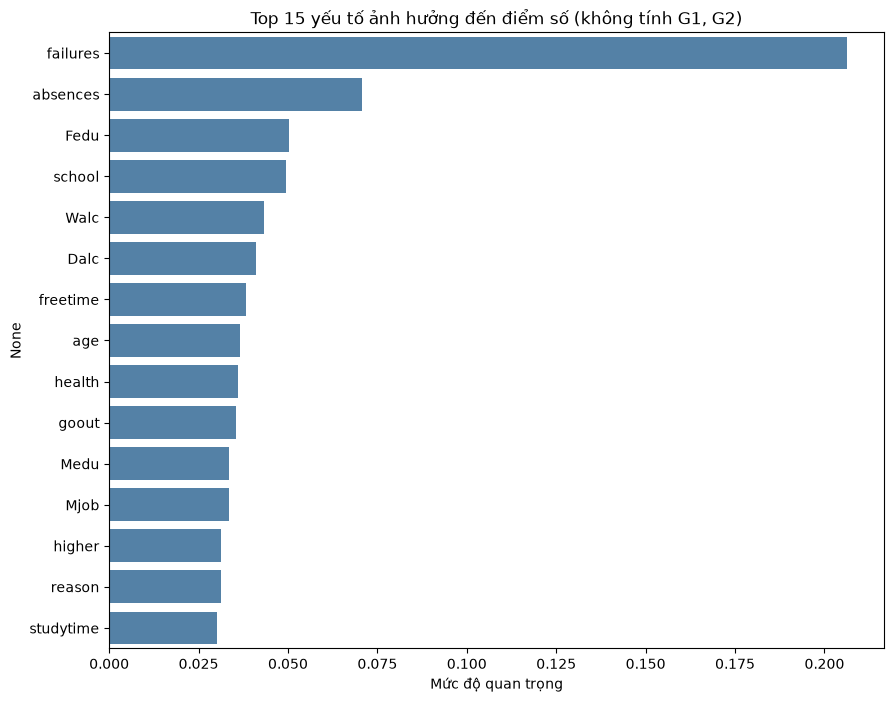

failures     0.206374
absences     0.070815
Fedu         0.050305
school       0.049572
Walc         0.043363
Dalc         0.041082
freetime     0.038320
age          0.036469
health       0.036144
goout        0.035554
Medu         0.033470
Mjob         0.033377
higher       0.031289
reason       0.031149
studytime    0.030147
dtype: float64


In [ ]:
17.
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color='steelblue')
plt.title('Top 15 yếu tố ảnh hưởng đến điểm số (không tính G1, G2)')
plt.xlabel('Mức độ quan trọng')
plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importances.head(15))

<Figure size 700x600 with 0 Axes>

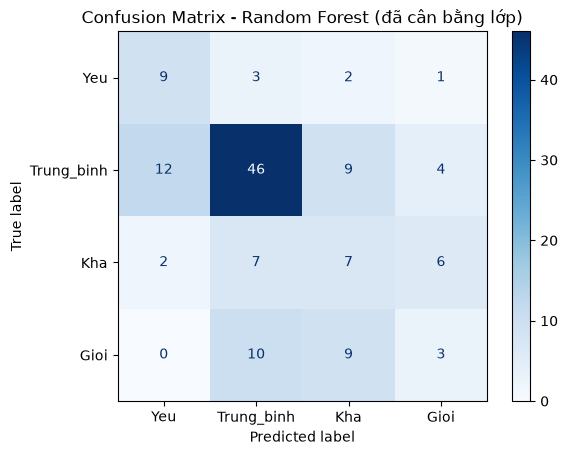

In [ ]:
18.
# Vẽ Confusion Matrix cho mô hình phân loại tốt nhất (Random Forest cân bằng)
from sklearn.metrics import ConfusionMatrixDisplay

labels_order = ['Yeu', 'Trung_binh', 'Kha', 'Gioi']
cm = confusion_matrix(y_test_clf, y_pred_rfc_balanced, labels=labels_order)

plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest (đã cân bằng lớp)')
plt.savefig('../results/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

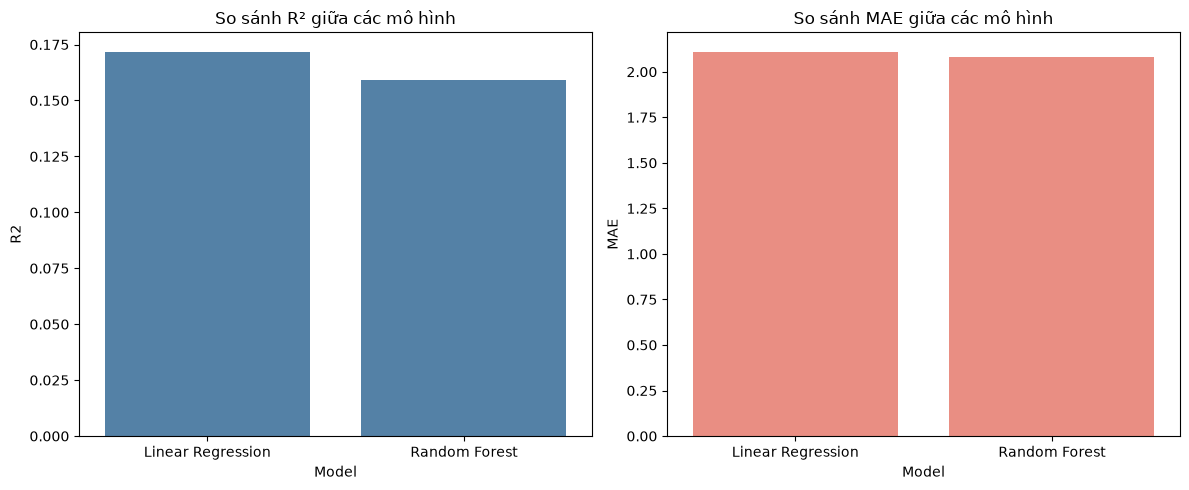

In [ ]:
19.
# Biểu đồ so sánh R² giữa các mô hình
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2': [results_reg['Linear Regression'][2], results_reg['Random Forest'][2]],
    'MAE': [results_reg['Linear Regression'][0], results_reg['Random Forest'][0]]
})

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(data=comparison_df, x='Model', y='R2', ax=axes[0], color='steelblue')
axes[0].set_title('So sánh R² giữa các mô hình')
sns.barplot(data=comparison_df, x='Model', y='MAE', ax=axes[1], color='salmon')
axes[1].set_title('So sánh MAE giữa các mô hình')
plt.tight_layout()
plt.savefig('../results/figures/so_sanh_mo_hinh.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
20.
import joblib

joblib.dump(rf_model, '../results/models/random_forest_regressor.pkl')
joblib.dump(rfc_balanced, '../results/models/random_forest_classifier.pkl')
joblib.dump(label_encoders, '../results/models/label_encoders.pkl')

print("Đã lưu các mô hình vào results/models/")

Đã lưu các mô hình vào results/models/
